In [2]:
import pandas as pd
from google.colab import files

In [3]:
file = files.upload()

Saving Final_Augmented_dataset_Diseases_and_Symptoms.csv to Final_Augmented_dataset_Diseases_and_Symptoms.csv


In [4]:
df = pd.read_csv("Final_Augmented_dataset_Diseases_and_Symptoms.csv")
df.head()

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
0,panic disorder,1,0,1,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
1,panic disorder,0,0,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
2,panic disorder,1,1,1,1,0,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
3,panic disorder,1,0,0,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
4,panic disorder,1,1,0,0,0,0,1,1,1,...,0,0,0,0,0,0,0,0,0,0


In [5]:
df.shape

(246945, 378)

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246945 entries, 0 to 246944
Columns: 378 entries, diseases to neck weakness
dtypes: int64(377), object(1)
memory usage: 712.2+ MB


In [7]:
df.columns

Index(['diseases', 'anxiety and nervousness', 'depression',
       'shortness of breath', 'depressive or psychotic symptoms',
       'sharp chest pain', 'dizziness', 'insomnia',
       'abnormal involuntary movements', 'chest tightness',
       ...
       'stuttering or stammering', 'problems with orgasm', 'nose deformity',
       'lump over jaw', 'sore in nose', 'hip weakness', 'back swelling',
       'ankle stiffness or tightness', 'ankle weakness', 'neck weakness'],
      dtype='object', length=378)

In [8]:
df.isnull().sum().sum()

np.int64(0)

In [9]:
top_100 = df['diseases'].value_counts().head(100).index
df = df[df['diseases'].isin(top_100)].reset_index(drop=True)

In [10]:
df.duplicated().sum()
duplicated_rows = df[df.duplicated()]
display(duplicated_rows.head())

,diseases,anxiety and nervousness,depression,shortness of breath,depressive or psychotic symptoms,sharp chest pain,dizziness,insomnia,abnormal involuntary movements,chest tightness,...,stuttering or stammering,problems with orgasm,nose deformity,lump over jaw,sore in nose,hip weakness,back swelling,ankle stiffness or tightness,ankle weakness,neck weakness
147,panic disorder,1,0,1,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
181,panic disorder,1,1,1,1,0,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
247,panic disorder,1,1,1,1,0,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
281,panic disorder,0,0,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
283,panic disorder,0,1,1,1,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0


In [11]:
duplicates = df.groupby(df.columns[:-1].tolist())['diseases'].nunique()
print("mutliple diseases:",(duplicates >1).sum())

mutliple diseases: 0


In [12]:
df = df.drop_duplicates()


In [13]:
df.shape

(96035, 378)

In [14]:
df.dtypes.value_counts()

,count
int64,377
object,1


In [15]:
len(df.columns)-1

377

In [16]:
df['diseases'].value_counts()

,count
diseases,
cystitis,1219
vulvodynia,1218
nose disorder,1218
complex regional pain syndrome,1217
spondylosis,1216
...,...
blepharitis,802
psychotic disorder,802
neurosis,801


In [17]:
counts = df['diseases'].value_counts()
valid_classes = counts[counts >= 2].index
df = df[df['diseases'].isin(valid_classes)]
print("new shape:",df.shape)
print("mim class count:",df['diseases'].value_counts().min())

new shape: (96035, 378)
mim class count: 792


In [18]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [19]:
X = df.drop("diseases",axis=1)
y = df["diseases"]

In [20]:
print("features:",X.shape)
print("target:",y.shape)

features: (96035, 377)
target: (96035,)


In [21]:
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y)
print(len(label_encoder.classes_))

100


In [22]:
print(label_encoder.classes_)

['actinic keratosis' 'acute bronchiolitis' 'acute bronchitis'
 'acute bronchospasm' 'acute kidney injury' 'acute pancreatitis'
 'acute sinusitis' 'acute stress reaction' 'allergy' 'angina' 'anxiety'
 'appendicitis' 'arthritis of the hip' 'asthma'
 'benign prostatic hyperplasia (bph)' 'blepharitis' 'brachial neuritis'
 'bursitis' 'cholecystitis' 'chronic back pain' 'chronic constipation'
 'chronic obstructive pulmonary disease (copd)' 'common cold'
 'complex regional pain syndrome' 'concussion' 'conjunctivitis'
 'conjunctivitis due to allergy' 'contact dermatitis' 'cornea infection'
 'croup' 'cystitis' 'degenerative disc disease' 'dental caries'
 'depression' 'developmental disability' 'diverticulitis' 'drug reaction'
 'ear drum damage' 'eczema' 'esophagitis'
 'eustachian tube dysfunction (ear disorder)'
 'fungal infection of the hair' 'gallstone' 'gastrointestinal hemorrhage'
 'gout' 'heart attack' 'heart failure' 'hemorrhoids' 'herniated disk'
 'hiatal hernia' 'hyperemesis gravidarum'

In [23]:
import joblib
import os
os.makedirs("models",exist_ok=True)
joblib.dump(label_encoder,'./models/label_encoder.pk1')
print("saved")

saved


In [24]:
file = files.download('./models/label_encoder.pk1')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [25]:
X_train,X_test,y_train,y_test = train_test_split(X,y_encoded,test_size=0.2,random_state=42,stratify=y_encoded)

In [26]:
X_train.shape,X_test.shape,y_train.shape,y_test.shape

((76828, 377), (19207, 377), (76828,), (19207,))

In [27]:
categorical_colms = X_train.select_dtypes(include=['object']).columns
print(len(categorical_colms))
print(X_train.isnull().sum().sum())

0
0


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score,classification_report,accuracy_score,precision_score,recall_score,f1_score,confusion_matrix

In [29]:
print(df['diseases'].nunique())

100


In [64]:
lr = LogisticRegression(max_iter=1000,random_state=42,multi_class="multinomial")
lr.fit(X_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(max_iter=1000, multi_class='multinomial', random_state=42)

In [65]:
lr_pred = lr.predict(X_test)

In [ ]:
print("logistic regression")
accuracy_lr = accuracy_score(y_test,lr_pred)
precision_score_lr = precision_score(y_test,lr_pred,average='weighted')
recall_score_lr = recall_score(y_test,lr_pred,average='weighted')
f1_score_lr = f1_score(y_test,lr_pred,average='weighted')
print(f"Accuracy: {accuracy_lr}")
print(f"Precision: {precision_score_lr}")
print(f"Recall: {recall_score_lr}")
print(f"F1 Score: {f1_score_lr}")

In [77]:
!pip install xgboost
from xgboost import XGBClassifier

In [ ]:

xgb = XGBClassifier(n_estimators=200,max_depth=8,learning_rate=0.1,random_state=42,objective='multi:softprob',tree_method='hist',reg_alpha=0,reg_lambda=1,subsample=0.8,min_child_weight=3,n_jobs=-1)
xgb.fit(X_train,y_train)

In [106]:
xgb_pred = xgb.predict(X_test)

In [107]:
print(type(precision_score))

<class 'function'>


In [108]:
accuracy_xgb = accuracy_score(y_test,xgb_pred)
precision_score_xgb = precision_score(y_test,xgb_pred,average='weighted')
recall_score_xgb = recall_score(y_test,xgb_pred,average='weighted')
f1_score_xgb = f1_score(y_test,xgb_pred,average='weighted')
print("xgboost")
print(f"Accuracy: {accuracy_xgb}")
print(f"Precision: {precision_score_xgb}")
print(f"Recall: {recall_score_xgb}")
print(f"F1 Score: {f1_score_xgb}")

xgboost
Accuracy: 0.8652053938668194
Precision: 0.8658940747967664
Recall: 0.8652053938668194
F1 Score: 0.865229270385569


In [101]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=300,random_state=42,max_depth=20,min_samples_split=5,min_samples_leaf=2,)
rf.fit(X_train,y_train)

RandomForestClassifier(max_depth=20, min_samples_leaf=2, min_samples_split=5,
                       n_estimators=300, random_state=42)

In [102]:
rf_pred = rf.predict(X_test)

In [109]:
accuracy_rf = accuracy_score(y_test,rf_pred)
precision_score_rf = precision_score(y_test,rf_pred,average='weighted')
recall_score_rf = recall_score(y_test,rf_pred,average='weighted')
f1_score_rf = f1_score(y_test,rf_pred,average='weighted')
print("random forrest")
print(f"Accuracy: {accuracy_rf}")
print(f"Precision: {precision_score_rf}")
print(f"Recall: {recall_score_rf}")
print(f"F1 Score: {f1_score_rf}")

random forrest
Accuracy: 0.8610923100952778
Precision: 0.8922979518356651
Recall: 0.8610923100952778
F1 Score: 0.8662335400657695


In [110]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout,BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

In [111]:
model = Sequential([
    Dense(256,activation='relu',input_shape=(X_train.shape[1],)),
    BatchNormalization(),
    Dropout(0.3),
    Dense(128,activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(64,activation='relu'),
    Dropout(0.2),
    Dense(len(label_encoder.classes_),activation='softmax')
])


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [112]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

In [113]:
early_stop = EarlyStopping(monitor='val_loss',patience=5,verbose=1,restore_best_weights=True)

In [115]:
history = model.fit(X_train,y_train,epochs=50,batch_size=32,validation_split=0.2,verbose=1)

Epoch 1/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 22s 12ms/step - accuracy: 0.8852 - loss: 0.2660 - val_accuracy: 0.8855 - val_loss: 0.2186
Epoch 2/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 36s 9ms/step - accuracy: 0.8856 - loss: 0.2662 - val_accuracy: 0.8857 - val_loss: 0.2195
Epoch 3/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8831 - loss: 0.2652 - val_accuracy: 0.8859 - val_loss: 0.2175
Epoch 4/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.8844 - loss: 0.2637 - val_accuracy: 0.8857 - val_loss: 0.2164
Epoch 5/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8861 - loss: 0.2607 - val_accuracy: 0.8872 - val_loss: 0.2182
Epoch 6/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 20s 8ms/step - accuracy: 0.8867 - loss: 0.2569 - val_accuracy: 0.8840 - val_loss: 0.2154
Epoch 7/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8859 - loss: 0.2594 - val_accuracy: 0.8840 - val_loss: 0.2171
Epoch 8/50
1921/1921 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8867 - loss: 

In [126]:
loss,accuracy_dn = model.evaluate(X_test,y_test)
print(f"Test Loss: {loss}")
print(f"Test Accuracy: {accuracy_dn}")

601/601 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8919 - loss: 0.2043
Test Loss: 0.20433221757411957
Test Accuracy: 0.8918623328208923


In [127]:
y_pred_dl = np.argmax(model.predict(X_test),axis=1)

601/601 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step


In [118]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred_dl))

              precision    recall  f1-score   support

           0       0.85      0.82      0.83       162
           1       1.00      0.89      0.94       241
           2       0.89      0.70      0.79       243
           3       0.70      0.72      0.71       162
           4       0.96      0.99      0.98       162
           5       0.98      0.83      0.90       241
           6       0.86      0.94      0.90       166
           7       0.91      0.97      0.94       160
           8       0.98      0.98      0.98       161
           9       0.96      0.92      0.93       165
          10       0.95      0.92      0.93       240
          11       0.79      0.90      0.84       162
          12       1.00      0.96      0.98       242
          13       0.60      0.96      0.73       163
          14       1.00      0.99      1.00       241
          15       0.79      0.96      0.87       160
          16       0.96      0.89      0.92       165
          17       1.00    

In [119]:
cm = confusion_matrix(y_test,y_pred_dl)

<Figure size 2000x2000 with 0 Axes>

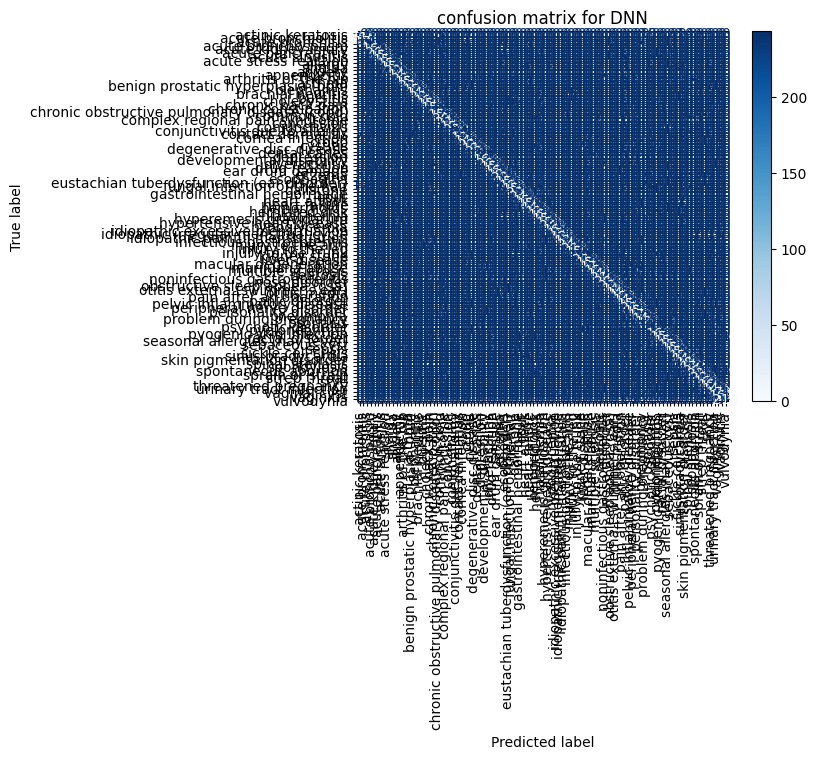

In [124]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=label_encoder.classes_)
plt.figure(figsize=(20,20))
disp.plot(cmap='Blues',xticks_rotation=90)
plt.title("confusion matrix for DNN")
plt.show()


In [128]:
results = [{
    "model":"logistic regression",
    "accuracy":accuracy_lr,
    "precision":precision_score_lr,
    "recall":recall_score_lr,
    "f1_score":f1_score_lr
},{
    model:"xgboost",
    "accuracy":accuracy_xgb,
    "precision":precision_score_xgb,
    "recall":recall_score_xgb,
    "f1_score":f1_score_xgb
},{
    "model":"random forrest",
    "accuracy":accuracy_rf,
    "precision":precision_score_rf,
    "recall":recall_score_rf,
    "f1_score":f1_score_rf
},{
    "model":"DNN",
    "accuracy":accuracy_dn,
}]

comparision_df = pd.DataFrame(results)
comparision_df = comparision_df.sort_values(by='accuracy',ascending=False)
print(comparision_df)


                 model  accuracy  precision    recall  f1_score  \
0  logistic regression  0.893528   0.897418  0.893528  0.893722   
3                  DNN  0.891862        NaN       NaN       NaN   
1                  NaN  0.865205   0.865894  0.865205  0.865229   
2       random forrest  0.861092   0.892298  0.861092  0.866234   

  <Sequential name=sequential, built=True>  
0                                      NaN  
3                                      NaN  
1                                  xgboost  
2                                      NaN  


In [129]:
comparision_df.to_csv("comparision.csv",index=False)

In [130]:
import joblib
joblib.dump(lr,'./models/logistic_regression.pk1')
joblib.dump(xgb,'./models/xgboost.pk1')
joblib.dump(rf,'./models/random_forrest.pk1')


['./models/random_forrest.pk1']

In [131]:
xgb.save_model('./models/xgboost_model.json')

In [132]:
model.save('./models/DNN_model.keras')

In [133]:
joblib.dump(label_encoder,'./models/label_encoder.pk1')
joblib.dump(X.columns.tolist(),'./models/symptom_columns.pk1')

['./models/symptom_columns.pk1']

In [134]:
import shutil
shutil.make_archive("models","zip","models")

'/content/models.zip'

In [135]:
from google.colab import files
files.download("models.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>